# EDA — donnees_sru_compilees_2023_2025.csv
Urban Data Explorer · Data.gouv.fr / Ministère du Logement

> Loi SRU (Solidarité et Renouvellement Urbains) : obligations de logements sociaux (LLS)  
> pour les communes de + 3 500 habitants dans les agglomérations de + 50 000 habitants.  
> Dataset compilé sur 3 millésimes : 2023 · 2024 · 2025.


## 0. Imports & configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


## 1. Chargement

In [ ]:
FILE = '../brute/Nouveau dossier/donnees_sru_compilees_2023_2025.csv'

df = pd.read_csv(FILE, sep=';', engine='python')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

print(f'Shape : {df.shape}')
print(f'Colonnes ({len(df.columns)}) :')
for c in df.columns:
    print(f'  {c}')
df.head(3)


Shape : (6537, 43)
Colonnes (43) :
  Annee_Donnees
  code_insee_commune
  nom_commune
  code_departement
  region
  Population_municipale_01_01_2023
  Code_SIREN_EPCI
  Nom_EPCI
  EPCI_SRU
  Code_unite_urbaine
  Nom_unite_urbaine
  UU_SRU
  Commune_isolee_article_L_302_5_CCH
  Commune_entree_au_01_01_2022
  Commune_entree_au_01_01_2023
  Nombre_lls_ Inventaire_au_01_01_2022
  Taux_SRU_au_01_01_2022
  Commune_carencee_2023_2025
  Commune_exemptee_2023_2025
  Taux_cible_commune_2023_2025
  Commune_deficitaire_2023
  Population_municipale_01_01_2024
  Code_unité_urbaine
  Nom_unité_urbaine
  Commune_isolée_article_L_302_5_CCH
  Commune_entrée_au_01_01_2023
  Commune_entrée_au_01_01_2024
  Nombre_lls_ Inventaire_au_01_01_2023
  Taux_SRU_au_01_01_2023
  Commune_carencée_2023_2025
  Commune_exemptée_2023_2025
  Commune_déficitaire_2024
  Prélèvement_net_2024_dont_majoration
  hexagone_drom
  Departement
  Population_municipale_01_01_2025
  Commune_sru_au_01_01_2025
  Commune_sru_au_01_01_202

,Annee_Donnees,code_insee_commune,nom_commune,code_departement,region,Population_municipale_01_01_2023,Code_SIREN_EPCI,Nom_EPCI,EPCI_SRU,Code_unite_urbaine,...,hexagone_drom,Departement,Population_municipale_01_01_2025,Commune_sru_au_01_01_2025,Commune_sru_au_01_01_2024,Nombre_lls_ Inventaire_au_01_01_2024,Taux_SRU_au_01_01_2024,commune_deficitaire,Commune_carencée,Prélèvement_net_2025_dont_majoration
0,2023,01031,BELLIGNAT,01,Auvergne-Rhône-Alpes,3671.0,200042935,COMMUNAUTE D'AGGLOMERATION HAUT-BUGEY AGGLOMER...,1,01402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,01043,BEYNOST,01,Auvergne-Rhône-Alpes,4829.0,240100800,CC DE MIRIBEL ET DU PLATEAU,0,00760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,01053,BOURG-EN-BRESSE,01,Auvergne-Rhône-Alpes,41681.0,200071751,CA DU BASSIN DE BOURG-EN-BRESSE,1,01501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Infos générales

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6537 entries, 0 to 6536
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Annee_Donnees                         6537 non-null   int64  
 1   code_insee_commune                    6537 non-null   object 
 2   nom_commune                           6537 non-null   object 
 3   code_departement                      6537 non-null   object 
 4   region                                6537 non-null   object 
 5   Population_municipale_01_01_2023      2157 non-null   float64
 6   Code_SIREN_EPCI                       6537 non-null   int64  
 7   Nom_EPCI                              6537 non-null   object 
 8   EPCI_SRU                              6537 non-null   int64  
 9   Code_unite_urbaine                    2157 non-null   object 
 10  Nom_unite_urbaine                     2157 non-null   object 
 11  UU_SRU           

In [ ]:
print('Millésimes présents :')
print(df['Annee_Donnees'].value_counts().sort_index())
print()
print(f"Communes uniques (code INSEE) : {df['code_insee_commune'].nunique()}")
print(f"Régions : {df['region'].nunique()}")
print(f"EPCI : {df['Nom_EPCI'].nunique()}")


Millésimes présents :
Annee_Donnees
2023    2157
2024    2184
2025    2196
Name: count, dtype: int64

Communes uniques (code INSEE) : 2212
Régions : 22
EPCI : 633


## 3. Valeurs manquantes

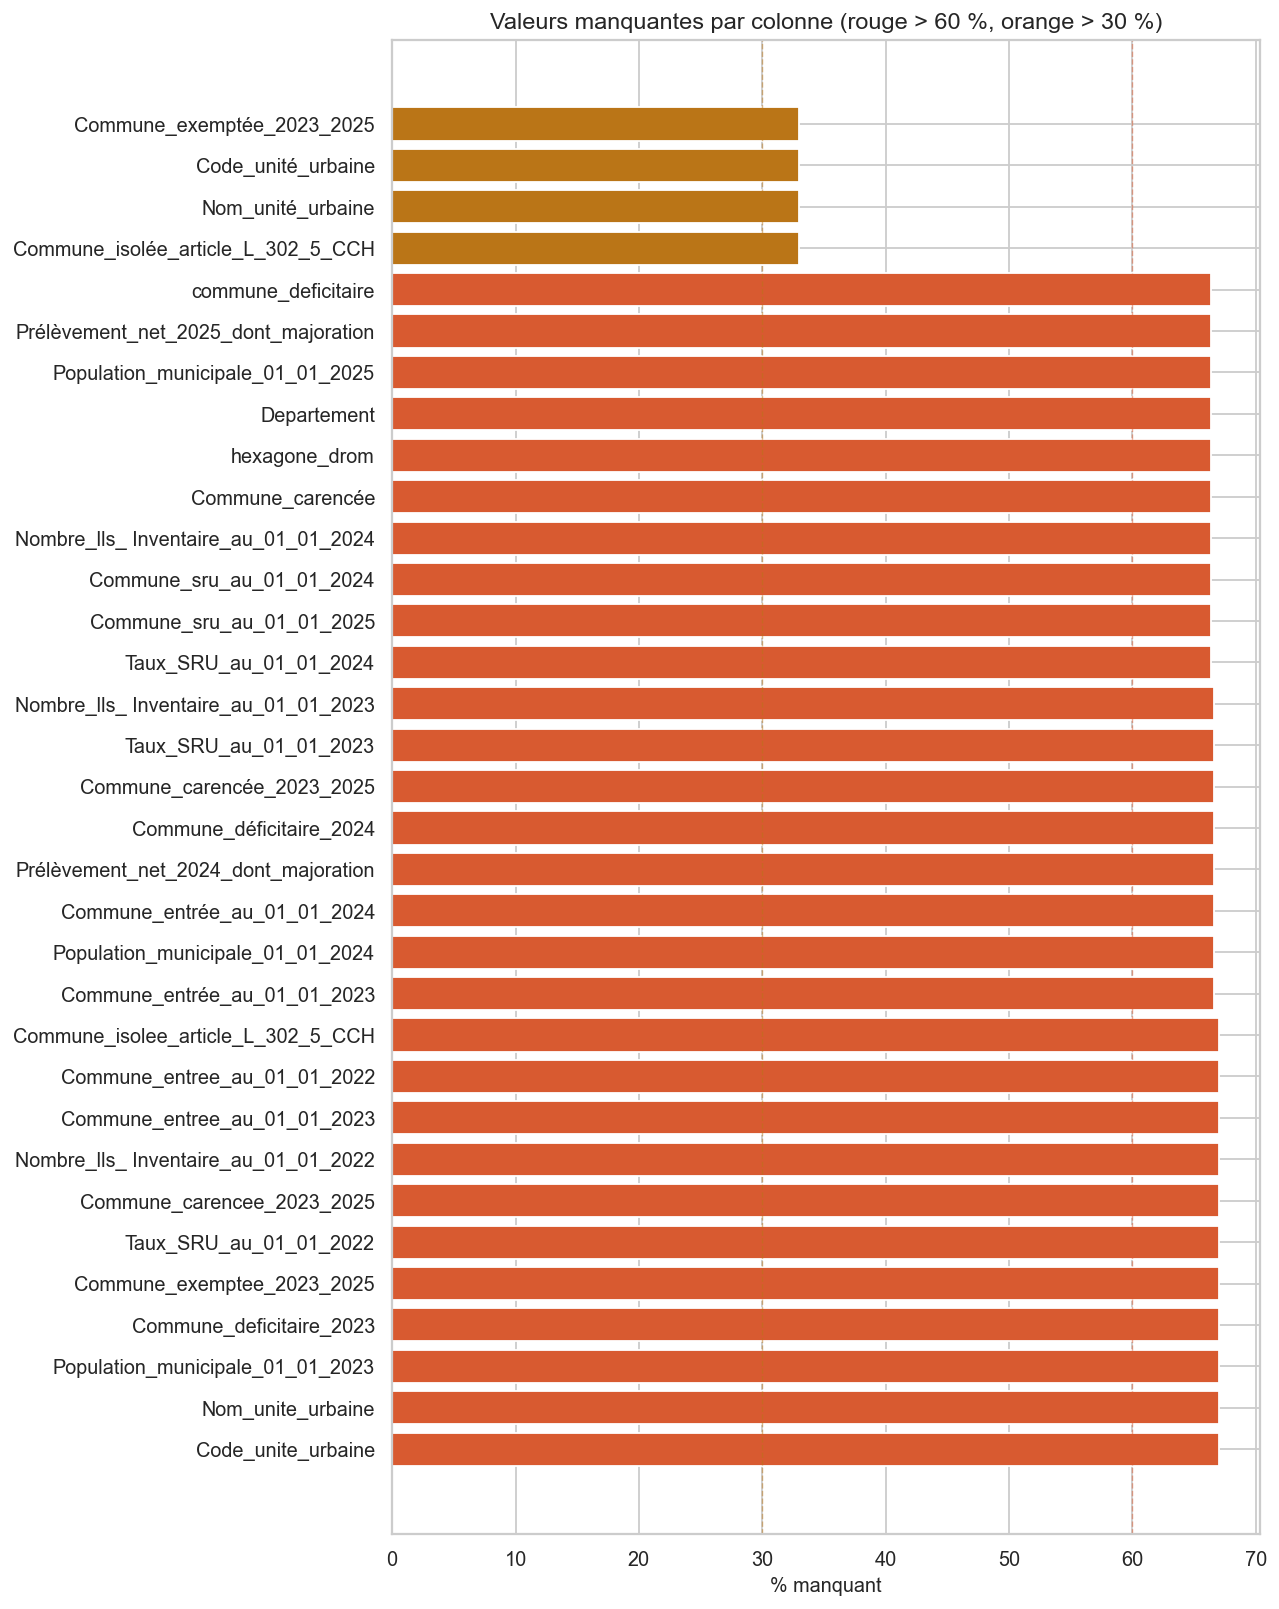

,% manquant
Code_unite_urbaine,67.0%
Nom_unite_urbaine,67.0%
Population_municipale_01_01_2023,67.0%
Commune_deficitaire_2023,67.0%
Commune_exemptee_2023_2025,67.0%
Taux_SRU_au_01_01_2022,67.0%
Commune_carencee_2023_2025,67.0%
Nombre_lls_ Inventaire_au_01_01_2022,67.0%
Commune_entree_au_01_01_2023,67.0%
Commune_entree_au_01_01_2022,67.0%


In [ ]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.38)))
colors = ['#D85A30' if v > 60 else '#BA7517' if v > 30 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 60 %, orange > 30 %)')
ax.axvline(60, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(30, color='#BA7517', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame().style.format('{:.1f}%'))


In [ ]:
# Explication structurelle des NaN
# Le dataset est compilé sur 3 millésimes dans le même fichier.
# Les colonnes propres à 2023 sont NaN pour les lignes 2024 et 2025, et vice versa.

for year in [2023, 2024, 2025]:
    n = (df['Annee_Donnees'] == year).sum()
    print(f'Millésime {year} : {n} lignes ({n/len(df)*100:.1f}%)')


Millésime 2023 : 2157 lignes (33.0%)
Millésime 2024 : 2184 lignes (33.4%)
Millésime 2025 : 2196 lignes (33.6%)


## 4. Doublons

In [ ]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')

# Vérif : une même commune peut apparaître 1 fois par millésime
dup_code = df.duplicated(subset=['code_insee_commune', 'Annee_Donnees']).sum()
print(f'(code_insee, millésime) dupliqués : {dup_code}')


Doublons : 0 (0.00%)
(code_insee, millésime) dupliqués : 0


## 5. Nettoyage & parsing des colonnes clés

In [ ]:
def parse_pct(s):
    """Convertit '21,30 %', '>25%', 'Nouvelle entrante' → float ou None."""
    if pd.isna(s): return None
    s = str(s).replace('%','').replace(' ','').replace('\xa0','').replace(',','.')
    s = s.replace('>','').replace('<','')
    if any(kw in s.lower() for kw in ['entrante','entr','exempt','pas']): return None
    try: return float(s)
    except: return None

def parse_eur(s):
    """Convertit '2 034 045,82 €', '- €' → float."""
    if pd.isna(s): return None
    s = str(s).replace('€','').replace('\xa0','').replace(' ','').replace(',','.')
    if s.strip() in ['-', '–', '']: return 0.0
    try: return float(s)
    except: return None

def parse_lls(s):
    """Parse le nombre de LLS (ignore 'Pas d'inventaire')."""
    if pd.isna(s): return None
    s = str(s).replace(' ','').replace('\xa0','')
    if any(kw in s.lower() for kw in ['pas','inv']): return None
    try: return float(s)
    except: return None

df['taux_2022'] = df['Taux_SRU_au_01_01_2022'].apply(parse_pct)
df['taux_2023'] = df['Taux_SRU_au_01_01_2023'].apply(parse_pct)
df['taux_2024'] = df['Taux_SRU_au_01_01_2024'].apply(parse_pct)

# Quelques valeurs aberrantes > 100 % (erreurs de source) → None
for col in ['taux_2022','taux_2023','taux_2024']:
    n_ab = (df[col] > 100).sum()
    if n_ab: print(f'⚠ {col} : {n_ab} valeurs > 100 % → remplacées par NaN')
    df.loc[df[col] > 100, col] = None

df['prel_2024'] = df['Prélèvement_net_2024_dont_majoration'].apply(parse_eur)
df['prel_2025'] = df['Prélèvement_net_2025_dont_majoration'].apply(parse_eur)
df['lls_2022']  = df['Nombre_lls_ Inventaire_au_01_01_2022'].apply(parse_lls)
df['lls_2023']  = df['Nombre_lls_ Inventaire_au_01_01_2023'].apply(parse_lls)
df['lls_2024']  = df['Nombre_lls_ Inventaire_au_01_01_2024'].apply(parse_lls)
df['pop_2023']  = pd.to_numeric(df['Population_municipale_01_01_2023'], errors='coerce')
df['pop_2025']  = pd.to_numeric(df['Population_municipale_01_01_2025'], errors='coerce')

print('Parsing terminé ✅')
print(f"taux_2022 : {df['taux_2022'].notna().sum()} valeurs valides")
print(f"taux_2023 : {df['taux_2023'].notna().sum()} valeurs valides")
print(f"taux_2024 : {df['taux_2024'].notna().sum()} valeurs valides")


⚠ taux_2024 : 2 valeurs > 100 % → remplacées par NaN
Parsing terminé ✅
taux_2022 : 2136 valeurs valides
taux_2023 : 2153 valeurs valides
taux_2024 : 2163 valeurs valides


## 6. Analyse structurelle — taux SRU

In [ ]:
# Taux cible : 20 % ou 25 %
taux_cible_clean = df['Taux_cible_commune_2023_2025'].str.strip().str.replace('\xa0','')
taux_cible_norm = taux_cible_clean.str.replace(',00','').str.replace(' ','')
print('Distribution des taux cibles :')
print(taux_cible_norm.value_counts())


Distribution des taux cibles :
Taux_cible_commune_2023_2025
25%    3394
20%    3143
Name: count, dtype: int64


In [ ]:
# Stats descriptives par millésime
print('─── Stats taux SRU par millésime ───')
for label, col in [('2022','taux_2022'),('2023','taux_2023'),('2024','taux_2024')]:
    s = df[col].dropna()
    below = (s < 20).sum()
    mid   = s.between(20, 25).sum()
    above = (s > 25).sum()
    print(f"\n{label}  (n={len(s):,})")
    print(f"  Moyenne   : {s.mean():.2f} %    Médiane : {s.median():.2f} %")
    print(f"  < 20 %    : {below:,} communes  ({below/len(s)*100:.1f} %)")
    print(f"  20–25 %   : {mid:,} communes  ({mid/len(s)*100:.1f} %)")
    print(f"  > 25 %    : {above:,} communes  ({above/len(s)*100:.1f} %)")


─── Stats taux SRU par millésime ───

2022  (n=2,136)
  Moyenne   : 21.27 %    Médiane : 19.26 %
  < 20 %    : 1,133 communes  (53.0 %)
  20–25 %   : 414 communes  (19.4 %)
  > 25 %    : 589 communes  (27.6 %)

2023  (n=2,153)
  Moyenne   : 21.62 %    Médiane : 19.62 %
  < 20 %    : 1,096 communes  (50.9 %)
  20–25 %   : 445 communes  (20.7 %)
  > 25 %    : 612 communes  (28.4 %)

2024  (n=2,163)
  Moyenne   : 21.93 %    Médiane : 20.00 %
  < 20 %    : 1,071 communes  (49.5 %)
  20–25 %   : 461 communes  (21.3 %)
  > 25 %    : 631 communes  (29.2 %)


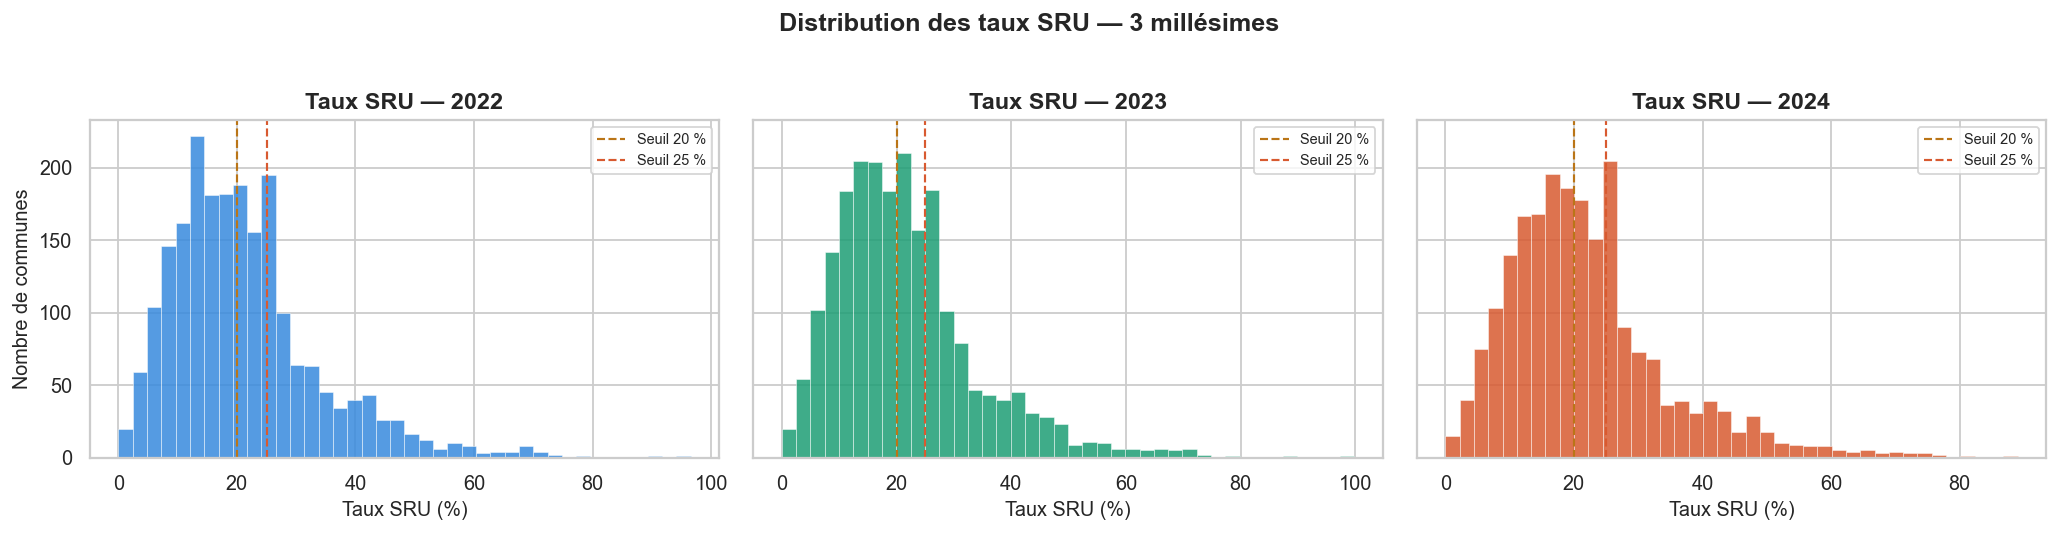

In [ ]:
# Distribution des taux SRU (histogrammes superposés)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

palette = {'2022':'#378ADD', '2023':'#1D9E75', '2024':'#D85A30'}
for ax, (label, col) in zip(axes, [('2022','taux_2022'),('2023','taux_2023'),('2024','taux_2024')]):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=palette[label], alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(20, color='#BA7517', linestyle='--', linewidth=1.2, label='Seuil 20 %')
    ax.axvline(25, color='#D85A30', linestyle='--', linewidth=1.2, label='Seuil 25 %')
    ax.set_title(f'Taux SRU — {label}', fontweight='bold')
    ax.set_xlabel('Taux SRU (%)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Nombre de communes')
plt.suptitle('Distribution des taux SRU — 3 millésimes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


C:\Users\ervin\AppData\Local\Temp\ipykernel_32648\1967858260.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=['2022','2023','2024'],


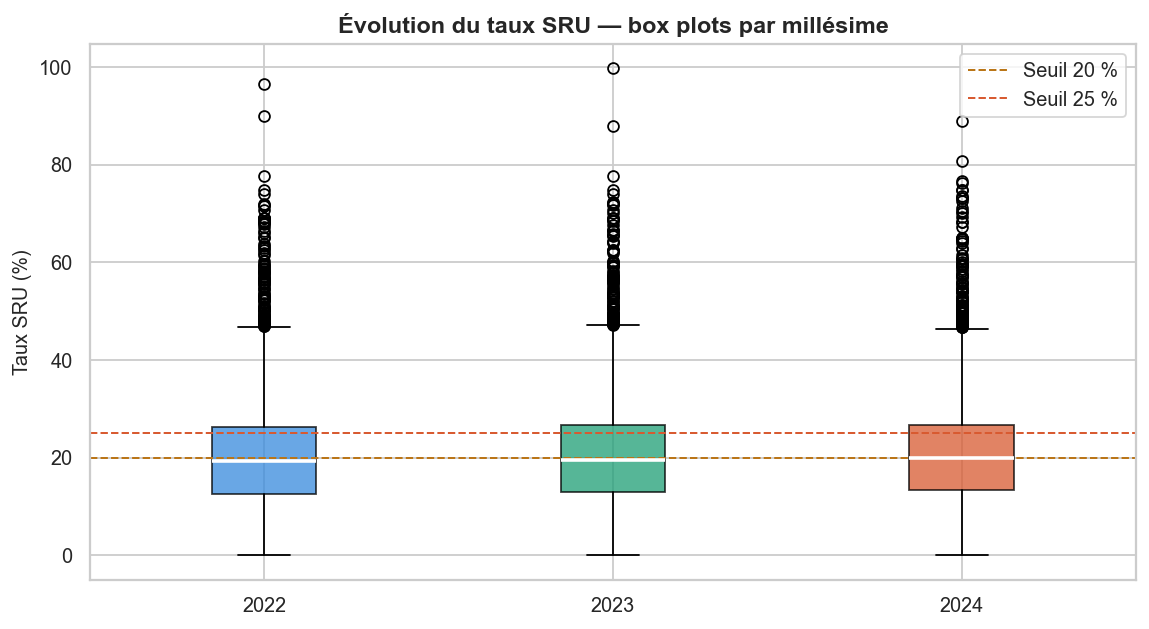

In [ ]:
# Box plots comparatifs
fig, ax = plt.subplots(figsize=(9, 5))
data_bp = [df['taux_2022'].dropna(), df['taux_2023'].dropna(), df['taux_2024'].dropna()]
bp = ax.boxplot(data_bp, labels=['2022','2023','2024'],
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

colors_bp = ['#378ADD','#1D9E75','#D85A30']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(20, color='#BA7517', linestyle='--', linewidth=1.1, label='Seuil 20 %')
ax.axhline(25, color='#D85A30', linestyle='--', linewidth=1.1, label='Seuil 25 %')
ax.set_ylabel('Taux SRU (%)')
ax.set_title('Évolution du taux SRU — box plots par millésime', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Communes carencées et déficitaires

In [ ]:
df23 = df[df['Annee_Donnees'] == 2023].copy()
df24 = df[df['Annee_Donnees'] == 2024].copy()
df25 = df[df['Annee_Donnees'] == 2025].copy()

print('═══ MILLÉSIME 2023 ═══')
print(f"  Communes carencées   : {df23['Commune_carencee_2023_2025'].sum():.0f}")
print(f"  Communes exemptées   : {df23['Commune_exemptee_2023_2025'].sum():.0f}")
print(f"  Communes déficitaires: {df23['Commune_deficitaire_2023'].sum():.0f}")

print('\n═══ MILLÉSIME 2024 ═══')
print(f"  Communes déficitaires: {df24['Commune_déficitaire_2024'].sum():.0f}")
print(f"  Communes carencées   : {df24['Commune_carencée_2023_2025'].sum():.0f}")

print('\n═══ MILLÉSIME 2025 ═══')
print(f"  Communes carencées   : {df25['Commune_carencée'].sum():.0f}")
print(f"  Communes déficitaires: {df25['commune_deficitaire'].sum():.0f}")


═══ MILLÉSIME 2023 ═══
  Communes carencées   : 278
  Communes exemptées   : 149
  Communes déficitaires: 1163

═══ MILLÉSIME 2024 ═══
  Communes déficitaires: 1152
  Communes carencées   : 336

═══ MILLÉSIME 2025 ═══
  Communes carencées   : 335
  Communes déficitaires: 1276


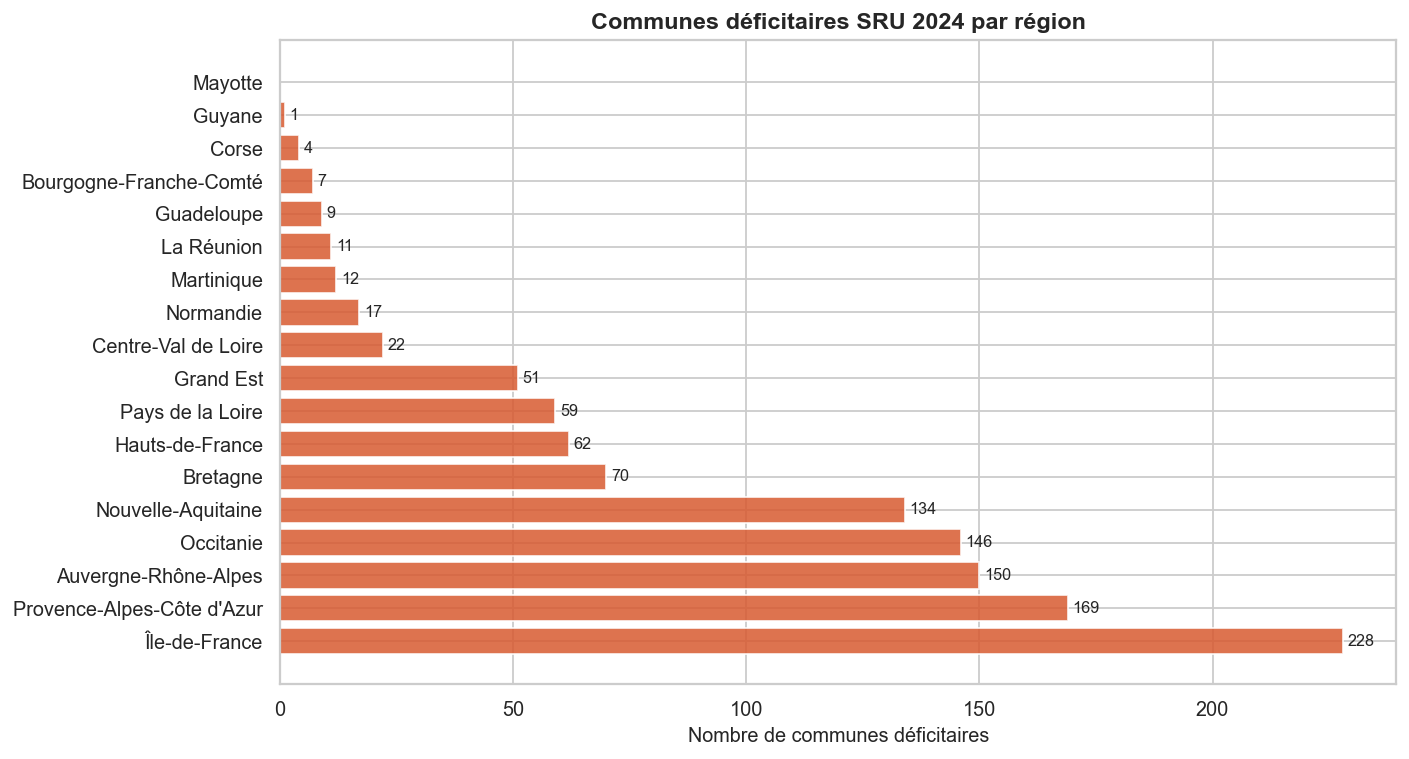

In [ ]:
# Déficitaires 2024 par région
deficit_reg = df24.groupby('region')['Commune_déficitaire_2024'].sum().sort_values(ascending=False).reset_index()
deficit_reg.columns = ['region','nb_deficitaires']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(deficit_reg['region'], deficit_reg['nb_deficitaires'], color='#D85A30', alpha=0.85)
ax.set_xlabel('Nombre de communes déficitaires')
ax.set_title('Communes déficitaires SRU 2024 par région', fontweight='bold')
for bar, val in zip(bars, deficit_reg['nb_deficitaires']):
    if val > 0:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


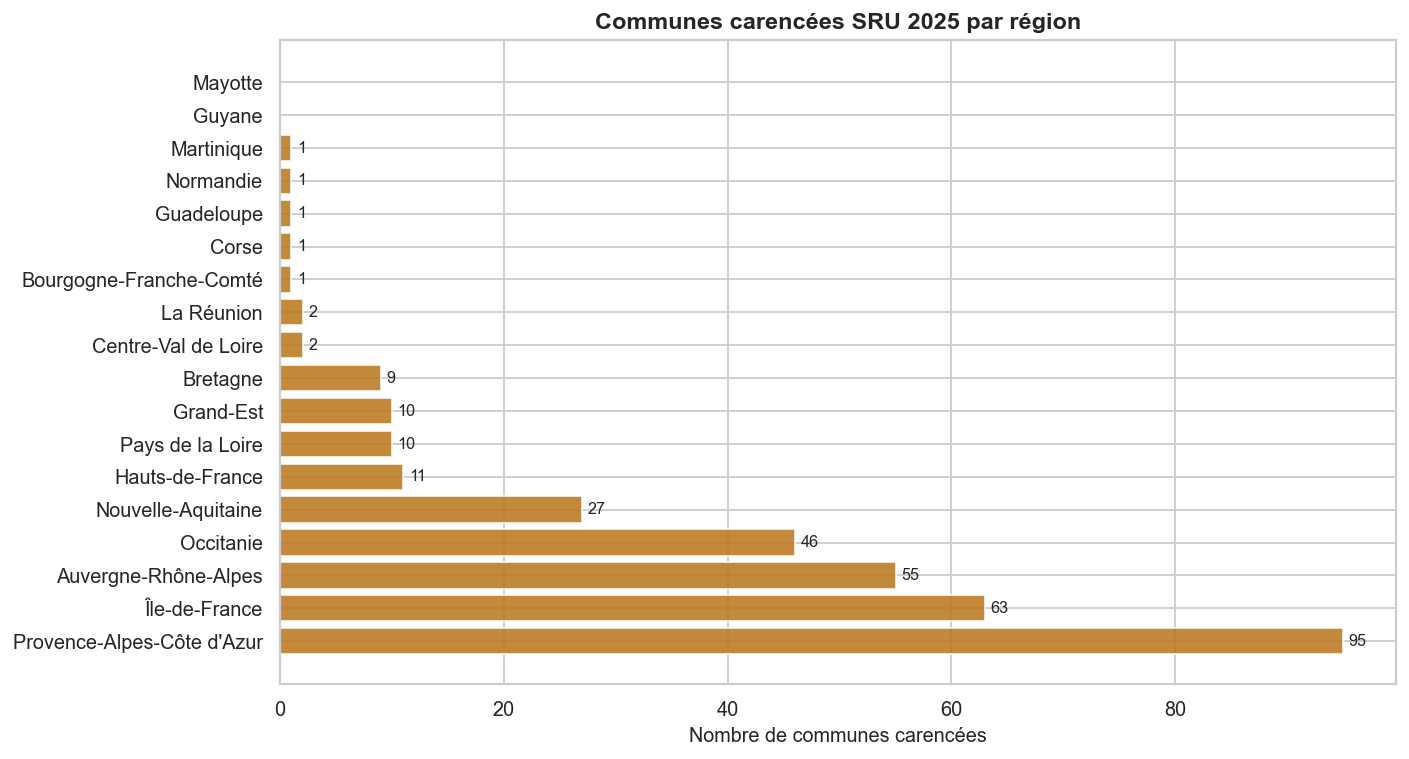

In [ ]:
# Carencées 2025 par région
carence_reg = df25.groupby('region')['Commune_carencée'].sum().sort_values(ascending=False).reset_index()
carence_reg.columns = ['region','nb_carencees']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(carence_reg['region'], carence_reg['nb_carencees'], color='#BA7517', alpha=0.85)
ax.set_xlabel('Nombre de communes carencées')
ax.set_title('Communes carencées SRU 2025 par région', fontweight='bold')
for bar, val in zip(bars, carence_reg['nb_carencees']):
    if val > 0:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 8. Prélèvements SRU (sanctions financières)

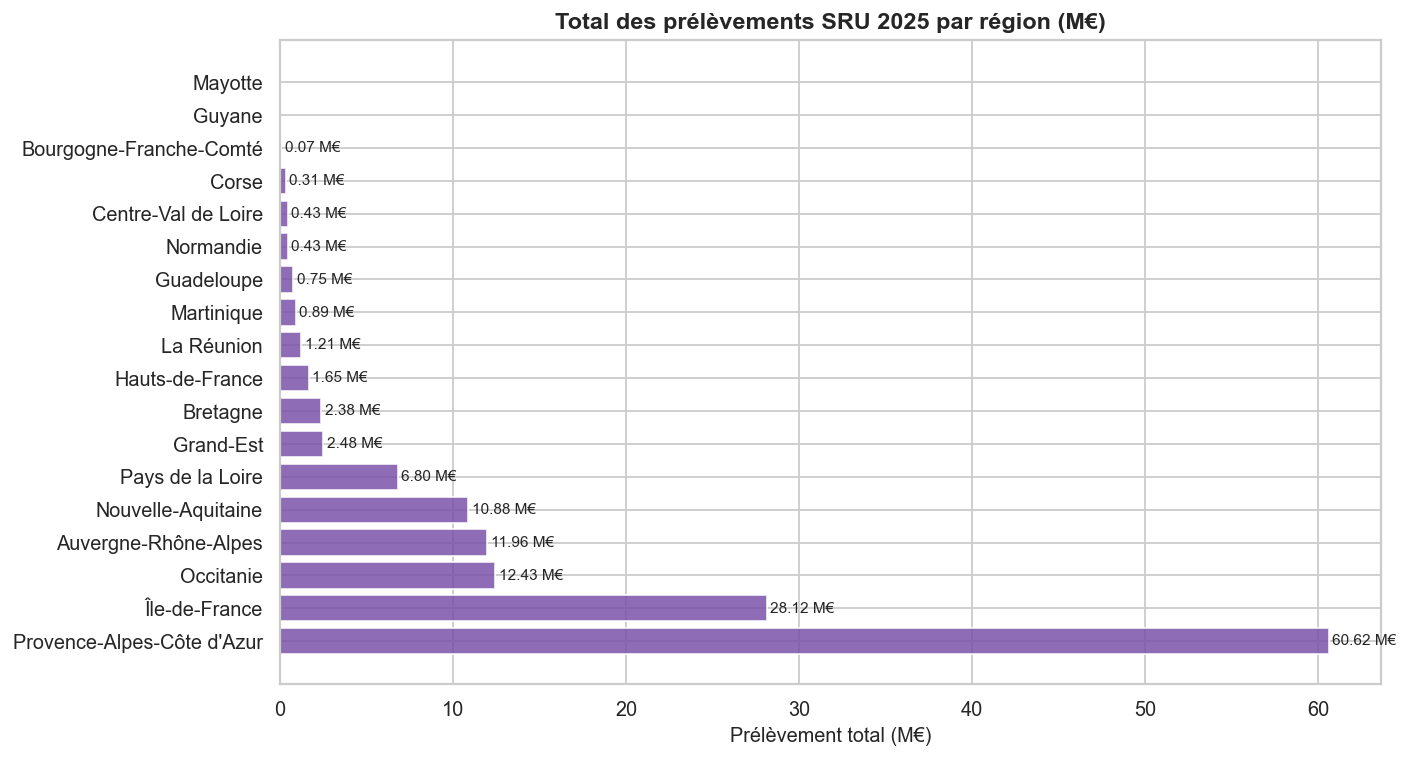

Prélèvement national total 2025 : 141,406,454 € (141.4 M€)


In [ ]:
# Prélèvement 2025 par région
prel_reg = df25.groupby('region')['prel_2025'].sum().sort_values(ascending=False).reset_index()
prel_reg.columns = ['region','prel_total']
prel_reg['prel_M'] = prel_reg['prel_total'] / 1e6

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(prel_reg['region'], prel_reg['prel_M'], color='#7B52A9', alpha=0.85)
ax.set_xlabel('Prélèvement total (M€)')
ax.set_title('Total des prélèvements SRU 2025 par région (M€)', fontweight='bold')
for bar, val in zip(bars, prel_reg['prel_M']):
    if val > 0:
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.2f} M€', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

total = prel_reg['prel_total'].sum()
print(f'Prélèvement national total 2025 : {total:,.0f} € ({total/1e6:.1f} M€)')


In [ ]:
# Top 10 communes — prélèvement 2025
top10 = df25.nlargest(10, 'prel_2025')[['nom_commune','region','prel_2025','Taux_SRU_au_01_01_2024']].copy()
top10['prel_2025'] = top10['prel_2025'].map(lambda x: f'{x:,.0f} €')
display(top10.reset_index(drop=True).rename(columns={
    'nom_commune': 'Commune',
    'region': 'Région',
    'prel_2025': 'Prélèvement 2025',
    'Taux_SRU_au_01_01_2024': 'Taux SRU 2024'
}))


,Commune,Région,Prélèvement 2025,Taux SRU 2024
0,NICE,Provence-Alpes-Côte d'Azur,"8,235,789 €","14,43%"
1,SAINT-MAUR-DES-FOSSÉS,Île-de-France,"5,483,200 €","10,28%"
2,TOULON,Provence-Alpes-Côte d'Azur,"2,965,710 €","17,53%"
3,BIARRITZ,Nouvelle-Aquitaine,"2,576,969 €","11,13%"
4,MANDELIEU-LA-NAPOULE,Provence-Alpes-Côte d'Azur,"2,080,028 €","9,35%"
5,VALLAURIS,Provence-Alpes-Côte d'Azur,"2,034,046 €","9,37%"
6,LE CANNET,Provence-Alpes-Côte d'Azur,"1,755,588 €","9,69%"
7,SAINT-CLOUD,Île-de-France,"1,659,838 €","17,55%"
8,SIX-FOURS-LES-PLAGES,Provence-Alpes-Côte d'Azur,"1,622,965 €","11,02%"
9,MENTON,Provence-Alpes-Côte d'Azur,"1,602,441 €","10,27%"


## 9. Logements sociaux (LLS) — inventaire

In [ ]:
print('─── LLS inventaire — stats descriptives ───')
for label, col in [('2022','lls_2022'), ('2023','lls_2023'), ('2024','lls_2024')]:
    s = df[col].dropna()
    print(f"{label}  n={len(s):,}  median={s.median():,.0f}  max={s.max():,.0f}")


─── LLS inventaire — stats descriptives ───
2022  n=2,063  median=661  max=264,854
2023  n=2,077  median=668  max=269,080
2024  n=2,088  median=691  max=271,906


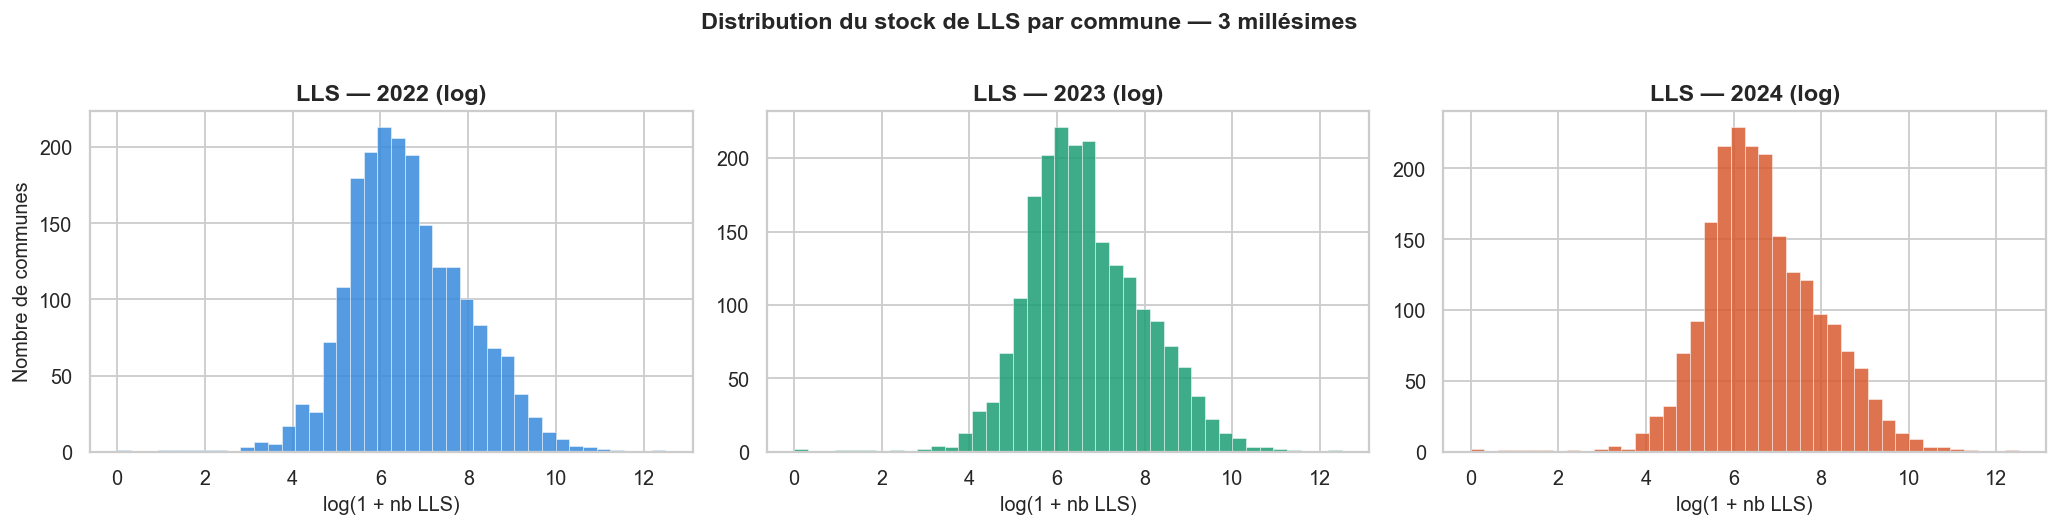

In [ ]:
# Distribution LLS (log scale pour lisibilité)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
palette = {'2022':'#378ADD', '2023':'#1D9E75', '2024':'#D85A30'}

for ax, (label, col) in zip(axes, [('2022','lls_2022'),('2023','lls_2023'),('2024','lls_2024')]):
    data = df[col].dropna()
    ax.hist(np.log1p(data), bins=40, color=palette[label], alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(f'LLS — {label} (log)', fontweight='bold')
    ax.set_xlabel('log(1 + nb LLS)')

axes[0].set_ylabel('Nombre de communes')
plt.suptitle('Distribution du stock de LLS par commune — 3 millésimes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 10. Analyse régionale — taux SRU moyen

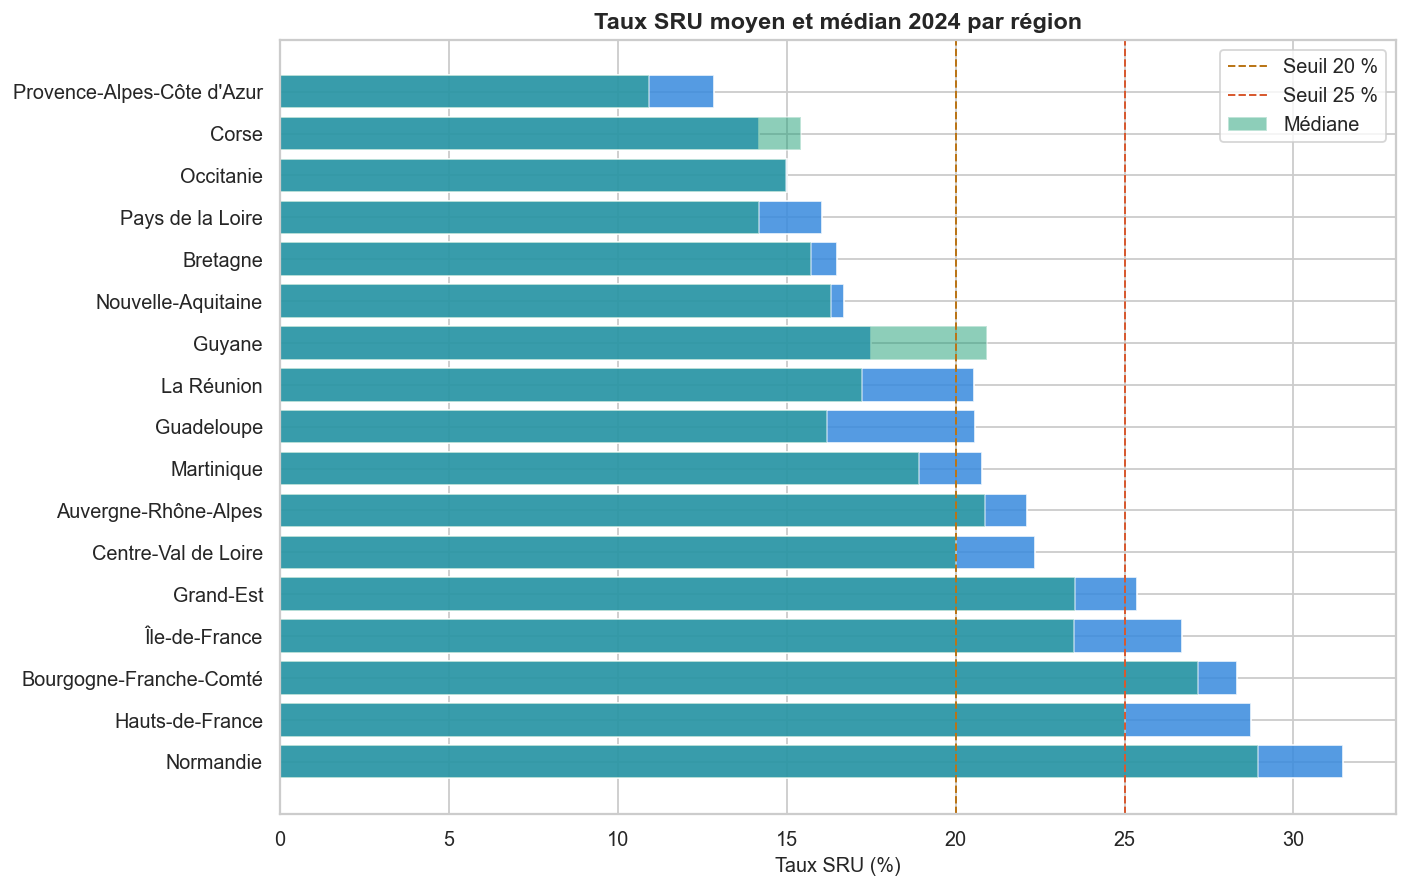

,Taux moyen,Médiane,N
region,,,
Normandie,31.47%,28.94%,85
Hauts-de-France,28.75%,25.00%,238
Bourgogne-Franche-Comté,28.32%,27.18%,58
Île-de-France,26.70%,23.52%,426
Grand-Est,25.37%,23.53%,148
Centre-Val de Loire,22.36%,20.00%,60
Auvergne-Rhône-Alpes,22.10%,20.87%,283
Martinique,20.78%,18.92%,25
Guadeloupe,20.58%,16.19%,24


In [24]:
# Taux moyen 2024 par région (uniquement lignes 2024 ou toutes lignes avec taux_2024)
reg_stats = (df.groupby('region')['taux_2024']
               .agg(['mean','median','count'])
               .rename(columns={'mean':'Taux moyen','median':'Médiane','count':'N'})
               .dropna()
               .sort_values('Taux moyen', ascending=False))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(reg_stats.index, reg_stats['Taux moyen'], color='#378ADD', alpha=0.85)
ax.barh(reg_stats.index, reg_stats['Médiane'], color='#1D9E75', alpha=0.5, label='Médiane')
ax.axvline(20, color='#BA7517', linestyle='--', linewidth=1.1, label='Seuil 20 %')
ax.axvline(25, color='#D85A30', linestyle='--', linewidth=1.1, label='Seuil 25 %')
ax.set_xlabel('Taux SRU (%)')
ax.set_title('Taux SRU moyen et médian 2024 par région', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

display(reg_stats.style.format({'Taux moyen':'{:.2f}%','Médiane':'{:.2f}%','N':'{:.0f}'}))


## 11. Résumé EDA

In [ ]:
print("=== RÉSUMÉ EDA — donnees_sru_compilees_2023_2025 ===\n")
print(f"Lignes totales              : {len(df):,} (3 millésimes × ~2 180 communes)")
print(f"Colonnes                    : {len(df.columns)}")
print(f"Régions couvertes           : {df['region'].nunique()}")
print()
print("── Taux SRU ──")
for label, col in [('2022','taux_2022'),('2023','taux_2023'),('2024','taux_2024')]:
    s = df[col].dropna()
    below = (s < 20).sum()
    print(f"  {label} — moyenne {s.mean():.2f}%, médiane {s.median():.2f}% — {below}/{len(s)} communes sous le seuil min (20%)")
print()
print("── Situation réglementaire ──")
print(f"  Communes carencées 2023    : {df23['Commune_carencee_2023_2025'].sum():.0f}")
print(f"  Communes déficitaires 2024 : {df24['Commune_déficitaire_2024'].sum():.0f}")
print(f"  Communes carencées 2025    : {df25['Commune_carencée'].sum():.0f}")
print()
total_prel_25 = df25['prel_2025'].sum()
print(f"── Prélèvements 2025 ──")
print(f"  Total national : {total_prel_25:,.0f} € ({total_prel_25/1e6:.1f} M€)")
print()
print("── Qualité données ──")
print(f"  LLS non renseigné ('Pas d inventaire') : ~{(df['Nombre_lls_ Inventaire_au_01_01_2024'].astype(str).str.lower().str.contains('pas|inv', na=False)).sum()} communes 2024")
print(f"  Structure millésimée : NaN structurels (chaque année dans sa partition de lignes)")


SyntaxError: unterminated string literal (detected at line 20) (3919153139.py, line 20)